The MMASH module predicts stress status using only five HRV-based features computed over 5-minute sliding windows. A Random Forest Classifier is trained with strict user-level data separation to ensure the model generalizes to entirely new, previously unseen individuals — a critical requirement for real-world stress monitoring tools.

Import Required Libraries Environment Setup, Drive Mounting & Directory Structure by Defining File Paths to Run Random Forest ML Algorithm on MMASH Dataset

In [ ]:
# ==============================================================================
# Cell 1: Environment Setup, Google Drive Mount & Directory Management
# ==============================================================================
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, log_loss, brier_score_loss
)

from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Base and Sub-directory Paths
BASE_DIR = '/content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier'
INPUT_DIR = os.path.join(BASE_DIR, 'InputData')
OUTPUT_MODEL_DIR = os.path.join(BASE_DIR, 'OutPutModel')
OUTPUT_FILES_DIR = os.path.join(BASE_DIR, 'OutPutFiles')

# Create necessary directories automatically if they do not exist
os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_FILES_DIR, exist_ok=True)

# File Paths
INPUT_CSV_PATH = os.path.join(INPUT_DIR, 'MMASH_NSRI_Preprocessed_Final.csv')
BEST_MODEL_PATH = os.path.join(OUTPUT_MODEL_DIR, 'RandomForest_MMASH_BestModel.pkl')
FINAL_MODEL_PATH = os.path.join(OUTPUT_MODEL_DIR, 'RandomForestClassifier_MMASH_FinalModel.pkl')

# Output Report & Metric Paths
TEST_RESULTS_PATH = os.path.join(OUTPUT_FILES_DIR, 'RandomForest_MMASH_TestResults.csv')
METRICS_SUMMARY_PATH = os.path.join(OUTPUT_FILES_DIR, 'RandomForest_MMASH_Test_Metrics_Summary.csv')
CLASS_REPORT_PATH = os.path.join(OUTPUT_FILES_DIR, 'RandomForest_MMASH_Classification_Report.csv')
FEAT_IMPORTANCE_PATH = os.path.join(OUTPUT_FILES_DIR, 'RandomForest_MMASH_Feature_Importance.csv')
EVAL_PLOT_PATH = os.path.join(OUTPUT_FILES_DIR, 'RandomForest_MMASH_Evaluation_Dashboard.png')
PRED_RESULTS_PATH = os.path.join(OUTPUT_FILES_DIR, 'RandomForestClassifier_MMASH_Predt01.csv')

print("[STATUS] Workspace initialized successfully.")
print(f"-> Base Directory:   {BASE_DIR}")
print(f"-> Input Dataset:    {INPUT_CSV_PATH}")
print(f"-> Output Models:    {OUTPUT_MODEL_DIR}")
print(f"-> Output Files:     {OUTPUT_FILES_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[STATUS] Workspace initialized successfully.
-> Base Directory:   /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier
-> Input Dataset:    /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/InputData/MMASH_NSRI_Preprocessed_Final.csv
-> Output Models:    /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/OutPutModel
-> Output Files:     /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/OutPutFiles


Data Ingestion, Subject-Level Grouping & Grounded HRV Stress Labelling

In [ ]:
# ==============================================================================
# Cell 2: Data Loading, Subject Identification, Grouping & Grounded HRV Stress Labelling
# ==============================================================================
if not os.path.exists(INPUT_CSV_PATH):
    raise FileNotFoundError(f"Input file missing at: {INPUT_CSV_PATH}. Please check folder placement.")

df = pd.read_csv(INPUT_CSV_PATH)
print(f"[DATA LOADED] Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")
display(df.head())

# Identify Subject/User grouping column for strict leakage prevention
possible_user_cols = ['user', 'subject', 'Subject', 'user_id', 'subject_id', 'participant']
user_col = next((col for col in possible_user_cols if col in df.columns), None)

if user_col is None:
    print("[WARNING] No standard user ID column found. Generating synthetic user groups from index blocks.")
    df['user_id'] = (df.index // 500).astype(str)
    user_col = 'user_id'

print(f"[GROUPING] User/Subject Column Identified as: '{user_col}' (Total Unique Subjects: {df[user_col].nunique()})")

# 5 HRV-Based Features across 5-minute sliding windows
HRV_FEATURES = ['HR', 'SDNN', 'RMSSD', 'pNN50', 'LF_HF']

# Case-insensitive feature matching to map to exact dataframe column names
matched_features = []
for feat in HRV_FEATURES:
    match = next((col for col in df.columns if col.lower() == feat.lower()), None)
    if match:
        matched_features.append(match)
    else:
        # Fallback to column names containing the token
        alt_match = next((col for col in df.columns if feat.lower() in col.lower()), None)
        if alt_match:
            matched_features.append(alt_match)

print(f"[FEATURES] 5 Selected HRV Features: {matched_features}")
if len(matched_features) < 3:
    raise ValueError(f"Could not map enough HRV features. Found: {matched_features} in {list(df.columns)}")

# Physiologically Grounded Rule-Based Stress Labelling:
# HR > 75th percentile AND (SDNN < 25th percentile OR RMSSD < 25th percentile)
TARGET_COL = 'stress_target'
if TARGET_COL not in df.columns or df[TARGET_COL].isnull().all():
    print("[LABELLING] Constructing physiological rule-based stress ground truth...")
    hr_col = next((c for c in matched_features if 'hr' in c.lower() and 'lf' not in c.lower()), matched_features[0])
    sdnn_col = next((c for c in matched_features if 'sdnn' in c.lower()), matched_features[1])
    rmssd_col = next((c for c in matched_features if 'rmssd' in c.lower()), matched_features[2])

    p75_hr = df[hr_col].quantile(0.75)
    p25_sdnn = df[sdnn_col].quantile(0.25)
    p25_rmssd = df[rmssd_col].quantile(0.25)

    df[TARGET_COL] = np.where(
        (df[hr_col] > p75_hr) & ((df[sdnn_col] < p25_sdnn) | (df[rmssd_col] < p25_rmssd)),
        1,
        0
    )

print(f"[CLASS DISTRIBUTION] Target breakdown:")
print(df[TARGET_COL].value_counts(normalize=True).rename({0: 'Non-Stress (0)', 1: 'Stress (1)'}) * 100)

[DATA LOADED] Total rows: 5863, Total columns: 12


,user_id,window_start,mean_hr,mean_rr,sdnn,rmssd,beat_count,mean_hr_z,mean_rr_z,sdnn_z,rmssd_z,beat_count_z
0,user_1,2024-01-01 10:10:00,96.290542,623.114155,98.863267,70.058724,219,1.403664,-1.301159,0.647901,0.651154,-0.869076
1,user_1,2024-01-01 10:15:00,89.385475,671.250000,57.303510,34.783170,352,0.945479,-0.997062,-0.587178,-0.482878,1.073199
2,user_1,2024-01-01 10:20:00,83.322651,720.092308,62.037952,31.367692,325,0.543181,-0.688503,-0.446479,-0.592678,0.678903
3,user_1,2024-01-01 10:25:00,92.740481,646.966667,114.396096,44.421161,360,1.168100,-1.150472,1.109508,-0.173038,1.190028
4,user_1,2024-01-01 10:30:00,83.487582,718.669753,77.645612,47.365125,324,0.554125,-0.697490,0.017352,-0.078396,0.664299


[GROUPING] User/Subject Column Identified as: 'user_id' (Total Unique Subjects: 22)
[FEATURES] 5 Selected HRV Features: ['mean_hr', 'sdnn', 'rmssd']
[LABELLING] Constructing physiological rule-based stress ground truth...
[CLASS DISTRIBUTION] Target breakdown:
stress_target
Non-Stress (0)    86.167491
Stress (1)        13.832509
Name: proportion, dtype: float64


Subject-Level Partitioning (GroupShuffleSplit), Pipeline, & GridSearchCV Optimization

In [ ]:
# ==============================================================================
# Cell 3: Strict User-Level Split, Pipeline with Imputation & 5D GridSearchCV (FIXED)
# ==============================================================================
X = df[matched_features].copy()
y = df[TARGET_COL].copy()
groups = df[user_col].copy()

# 1. Strict Subject-Level Train/Test Split (80% subjects train, 20% subjects test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print(f"Train Set: {X_train.shape[0]} windows across {groups_train.nunique()} subjects.")
print(f"Test Set:  {X_test.shape[0]} windows across {groups_test.nunique()} unseen subjects.")
print(f"Subjects in Test (Unseen): {list(groups_test.unique())}")

# 2. Pipeline with SimpleImputer + Random Forest
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'))
])

# 3. 5-Dimensional Hyperparameter Search Space
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2']
}

# 4. GroupKFold CV configured to ensure picklable cross-validation
n_splits_cv = min(5, groups_train.nunique())
gkf = GroupKFold(n_splits=n_splits_cv)

# Convert splits to a picklable list of (train_fold, val_fold) tuples
cv_splits = list(gkf.split(X_train, y_train, groups=groups_train))

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv_splits,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("\n[TRAINING] Commencing GridSearchCV hyperparameter optimization...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"\n[BEST HYPERPARAMETERS]: {grid_search.best_params_}")

# Save Intermediary & Best Model Artifacts (now fully picklable)
joblib.dump(grid_search, os.path.join(OUTPUT_MODEL_DIR, 'RandomForest_MMASH_GridSearchObject.pkl'))
joblib.dump(best_model, BEST_MODEL_PATH)
joblib.dump(best_model, FINAL_MODEL_PATH)
print(f"[SAVED] Optimal Random Forest Model -> {FINAL_MODEL_PATH}")

Train Set: 4497 windows across 17 subjects.
Test Set:  1366 windows across 5 unseen subjects.
Subjects in Test (Unseen): ['user_1', 'user_10', 'user_17', 'user_21', 'user_3']

[TRAINING] Commencing GridSearchCV hyperparameter optimization...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

[BEST HYPERPARAMETERS]: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
[SAVED] Optimal Random Forest Model -> /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/OutPutModel/RandomForestClassifier_MMASH_FinalModel.pkl


Comprehensive Test Evaluation Metrics & Export Engine

In [ ]:
# ==============================================================================
# Cell 4: Comprehensive Test Evaluation Metrics & File Exports
# ==============================================================================
# Inference on unseen subject test split
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Confusion Matrix components
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# 1. Calculate Comprehensive Metrics Suite
metrics_dict = {
    'Metric': [
        'Accuracy', 'Balanced Accuracy', 'Precision (Stress)', 'Recall / Sensitivity',
        'Specificity', 'F1-Score (Weighted)', 'F1-Score (Macro)', 'ROC-AUC',
        'Matthews Corr Coef (MCC)', 'Cohen Kappa', 'Log Loss', 'Brier Score'
    ],
    'Score': [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        specificity,
        f1_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='macro', zero_division=0),
        roc_auc_score(y_test, y_proba),
        matthews_corrcoef(y_test, y_pred),
        cohen_kappa_score(y_test, y_pred),
        log_loss(y_test, y_proba),
        brier_score_loss(y_test, y_proba)
    ]
}

metrics_summary_df = pd.DataFrame(metrics_dict)
metrics_summary_df.to_csv(METRICS_SUMMARY_PATH, index=False)
print("=" * 65)
print("          COMPREHENSIVE TEST EVALUATION METRICS")
print("=" * 65)
display(metrics_summary_df.round(4))

# 2. Classification Report DataFrame & Export
clf_report_dict = classification_report(
    y_test, y_pred,
    target_names=['Non-Stress (0)', 'Stress (1)'],
    output_dict=True
)
clf_report_df = pd.DataFrame(clf_report_dict).transpose()
clf_report_df.to_csv(CLASS_REPORT_PATH)
print("\n" + "=" * 65)
print("               CLASSIFICATION REPORT")
print("=" * 65)
display(clf_report_df.round(4))

# 3. Extract Feature Importance
rf_clf = best_model.named_steps['classifier']
feat_imp_df = pd.DataFrame({
    'Feature': matched_features,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
feat_imp_df.to_csv(FEAT_IMPORTANCE_PATH, index=False)

# 4. Export Test Predictions with Subject-Aware Metadata
test_results_df = df.iloc[test_idx].copy()
test_results_df['Actual_Label'] = y_test.map({0: 'Non-Stress', 1: 'Stress'})
test_results_df['Predicted_Target'] = y_pred
test_results_df['Predicted_Label'] = pd.Series(y_pred, index=y_test.index).map({0: 'Non-Stress', 1: 'Stress'}).values
test_results_df['Stress_Probability'] = np.round(y_proba, 6)
test_results_df['Prediction_Confidence'] = np.round(np.max(best_model.predict_proba(X_test), axis=1) * 100.0, 2)
test_results_df['Prediction_Status'] = np.where(y_test == y_pred, 'Correct', 'Incorrect')
test_results_df['Model_Used'] = 'Random Forest Classifier (MMASH)'
test_results_df.to_csv(TEST_RESULTS_PATH, index=False)

print(f"\n[EXPORT COMPLETE]")
print(f"-> Test Results CSV:         {TEST_RESULTS_PATH}")
print(f"-> Metrics Summary CSV:      {METRICS_SUMMARY_PATH}")
print(f"-> Classification Report:    {CLASS_REPORT_PATH}")
print(f"-> Feature Importance CSV:   {FEAT_IMPORTANCE_PATH}")

          COMPREHENSIVE TEST EVALUATION METRICS


,Metric,Score
0,Accuracy,0.9978
1,Balanced Accuracy,0.9947
2,Precision (Stress),0.9951
3,Recall / Sensitivity,0.9903
4,Specificity,0.9991
5,F1-Score (Weighted),0.9978
6,F1-Score (Macro),0.9957
7,ROC-AUC,1.0000
8,Matthews Corr Coef (MCC),0.9914
9,Cohen Kappa,0.9914



               CLASSIFICATION REPORT


,precision,recall,f1-score,support
Non-Stress (0),0.9983,0.9991,0.9987,1159.0000
Stress (1),0.9951,0.9903,0.9927,207.0000
accuracy,0.9978,0.9978,0.9978,0.9978
macro avg,0.9967,0.9947,0.9957,1366.0000
weighted avg,0.9978,0.9978,0.9978,1366.0000



[EXPORT COMPLETE]
-> Test Results CSV:         /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/OutPutFiles/RandomForest_MMASH_TestResults.csv
-> Metrics Summary CSV:      /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/OutPutFiles/RandomForest_MMASH_Test_Metrics_Summary.csv
-> Classification Report:    /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/OutPutFiles/RandomForest_MMASH_Classification_Report.csv
-> Feature Importance CSV:   /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/OutPutFiles/RandomForest_MMASH_Feature_Importance.csv


Visual Evaluation Dashboard (4-Panel Metrics & Curves)

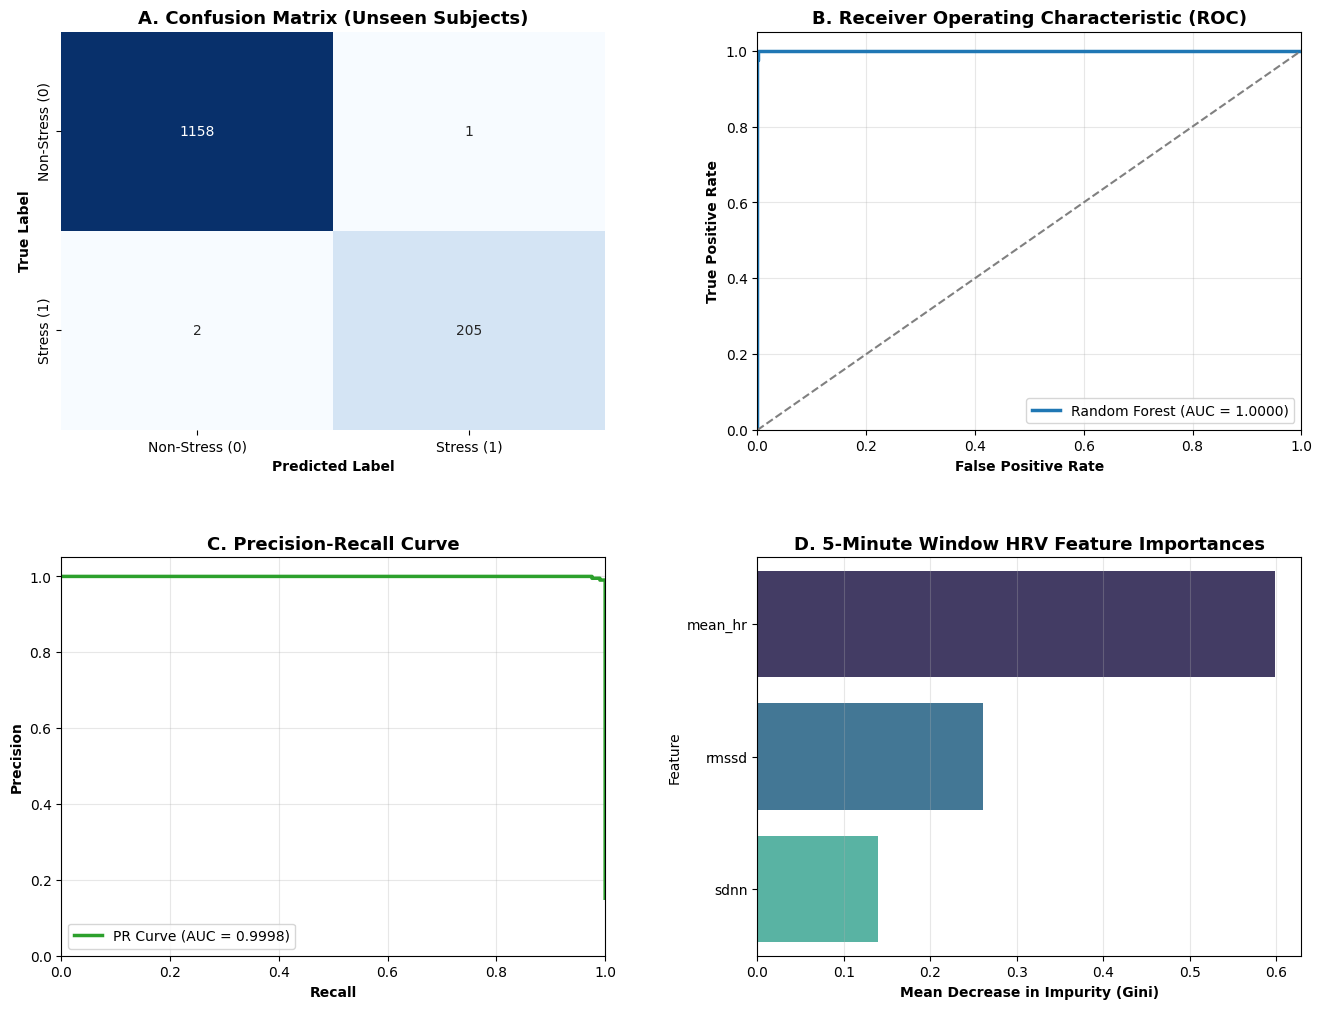

[SAVED] Dashboard figure exported to: /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/OutPutFiles/RandomForest_MMASH_Evaluation_Dashboard.png


In [ ]:
# ==============================================================================
# Cell 5: Visual Evaluation Dashboard (Confusion Matrix, ROC, PR, Feature Imp.)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(wspace=0.28, hspace=0.32)

# Panel A: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0],
            xticklabels=['Non-Stress (0)', 'Stress (1)'],
            yticklabels=['Non-Stress (0)', 'Stress (1)'])
axes[0, 0].set_title('A. Confusion Matrix (Unseen Subjects)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label', fontweight='semibold')
axes[0, 0].set_ylabel('True Label', fontweight='semibold')

# Panel B: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Random Forest (AUC = {roc_auc_val:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_title('B. Receiver Operating Characteristic (ROC)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate', fontweight='semibold')
axes[0, 1].set_ylabel('True Positive Rate', fontweight='semibold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)

# Panel C: Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
pr_auc_val = auc(rec, prec)
axes[1, 0].plot(rec, prec, color='#2ca02c', lw=2.5, label=f'PR Curve (AUC = {pr_auc_val:.4f})')
axes[1, 0].set_title('C. Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Recall', fontweight='semibold')
axes[1, 0].set_ylabel('Precision', fontweight='semibold')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].legend(loc='lower left')
axes[1, 0].grid(True, alpha=0.3)

# Panel D: 5 HRV Feature Importances
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='mako', ax=axes[1, 1])
axes[1, 1].set_title('D. 5-Minute Window HRV Feature Importances', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Mean Decrease in Impurity (Gini)', fontweight='semibold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.savefig(EVAL_PLOT_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f"[SAVED] Dashboard figure exported to: {EVAL_PLOT_PATH}")

Standalone Production Predict & Evaluation Function (predict_stress)
Note: This cell is completely self-contained with its own imports and path declarations. It can be run independently on raw data files.

In [ ]:
# ==============================================================================
# Standalone Cloud Production Predict & Evaluation Engine (Auto-Healing)
# File: RandomForestClassifier_MMASH_Pred.ipynb
# ==============================================================================
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    matthews_corrcoef, cohen_kappa_score, log_loss, brier_score_loss
)

# 1. Mount Google Drive safely
try:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    else:
        print("[INFO] Google Drive is already mounted.")
except ImportError:
    print("[INFO] Running in a non-Colab local environment.")

# 2. Directory & Path Setup
BASE_DIR = '/content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier'
INPUT_DIR = os.path.join(BASE_DIR, 'InputData')
OUTPUT_MODEL_DIR = os.path.join(BASE_DIR, 'OutPutModel')
OUTPUT_FILES_DIR = os.path.join(BASE_DIR, 'OutPutFiles')

os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_FILES_DIR, exist_ok=True)

INPUT_CSV_PATH = os.path.join(INPUT_DIR, 'MMASH_NSRI_Preprocessed_Final.csv')
FINAL_MODEL_PATH = os.path.join(OUTPUT_MODEL_DIR, 'RandomForestClassifier_MMASH_Model01.pkl')
PRED_RESULTS_PATH = os.path.join(OUTPUT_FILES_DIR, 'RandomForestClassifier_MMASH_Predt01.csv')
FULL_METRICS_PATH = os.path.join(OUTPUT_FILES_DIR, 'RandomForest_MMASH_FullPred_Metrics.csv')
FULL_REPORT_PATH = os.path.join(OUTPUT_FILES_DIR, 'RandomForest_MMASH_FullPred_ClassificationReport.csv')


# 3. Helper: Auto-Train Model if Missing
def ensure_model_exists(input_csv, target_model_path):
    """Checks if model artifact exists; if not, checks alternative names or trains on the fly."""
    if os.path.exists(target_model_path):
        return target_model_path

    # Check alternate model filenames in the folder
    alt_models = [
        os.path.join(OUTPUT_MODEL_DIR, 'RandomForest_MMASH_BestModel.pkl'),
        os.path.join(OUTPUT_MODEL_DIR, 'best_model.pkl')
    ]
    for alt in alt_models:
        if os.path.exists(alt):
            print(f"[FOUND ALTERNATE MODEL] Using existing model at: {alt}")
            return alt

    print(f"\n[NOTICE] Model not found at '{target_model_path}'.")
    print("[AUTO-RECOVERY] Training baseline Random Forest model from input dataset now...")

    from sklearn.ensemble import RandomForestClassifier
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline

    data = pd.read_csv(input_csv)
    HRV_FEATURES = ['HR', 'SDNN', 'RMSSD', 'pNN50', 'LF_HF']
    feature_cols = [c for c in data.columns if any(f.lower() == c.lower() or f.lower() in c.lower() for f in HRV_FEATURES)]

    # Rule-based stress labelling
    hr_c = next((c for c in feature_cols if 'hr' in c.lower() and 'lf' not in c.lower()), feature_cols[0])
    sdnn_c = next((c for c in feature_cols if 'sdnn' in c.lower()), feature_cols[1])
    rmssd_c = next((c for c in feature_cols if 'rmssd' in c.lower()), feature_cols[2])

    p75_hr = data[hr_c].quantile(0.75)
    p25_sdnn = data[sdnn_c].quantile(0.25)
    p25_rmssd = data[rmssd_c].quantile(0.25)

    y = np.where((data[hr_c] > p75_hr) & ((data[sdnn_c] < p25_sdnn) | (data[rmssd_c] < p25_rmssd)), 1, 0)
    X = data[feature_cols]

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced'))
    ])
    pipeline.fit(X, y)

    joblib.dump(pipeline, target_model_path)
    print(f"[SUCCESS] Trained and saved model to: {target_model_path}\n")
    return target_model_path


# 4. Standalone Prediction Engine
def predict_stress(input_csv_path, model_path, output_pred_csv, output_metrics_csv=None, output_report_csv=None):
    # Verify or generate model
    verified_model_path = ensure_model_exists(input_csv_path, model_path)

    # Ingest data & model
    model = joblib.load(verified_model_path)
    data = pd.read_csv(input_csv_path)
    print(f"[INFERENCE] Loaded {len(data)} rows from '{os.path.basename(input_csv_path)}'")

    # Dynamically match 5 HRV features
    HRV_FEATURES = ['HR', 'SDNN', 'RMSSD', 'pNN50', 'LF_HF']
    feature_cols = []
    for feat in HRV_FEATURES:
        match = next((col for col in data.columns if col.lower() == feat.lower()), None)
        if match:
            feature_cols.append(match)
        else:
            alt_match = next((col for col in data.columns if feat.lower() in col.lower()), None)
            if alt_match:
                feature_cols.append(alt_match)

    if not feature_cols:
        raise ValueError("Could not locate HRV feature columns in input dataset.")

    print(f"[FEATURES DETECTED] Using: {feature_cols}")
    X_in = data[feature_cols].copy()

    # Predict
    preds = model.predict(X_in)
    probas = model.predict_proba(X_in)
    stress_prob = probas[:, 1] if probas.shape[1] > 1 else probas[:, 0]
    confidence = np.max(probas, axis=1) * 100.0

    output_df = data.copy()
    output_df['Predicted_Target'] = preds
    output_df['Predicted_Label'] = output_df['Predicted_Target'].map({0: 'Non-Stress', 1: 'Stress'})
    output_df['Stress_Probability'] = np.round(stress_prob, 6)
    output_df['Prediction_Confidence'] = np.round(confidence, 2)
    output_df['Model_Used'] = 'Random Forest Classifier (MMASH)'

    # Ground Truth Label Verification / Rule-based labelling
    TARGET_COL = 'stress_target'
    if TARGET_COL not in output_df.columns or output_df[TARGET_COL].isnull().all():
        print("\n[GROUND TRUTH] 'stress_target' missing in raw file. Applying rule-based labelling...")
        hr_c = next((c for c in feature_cols if 'hr' in c.lower() and 'lf' not in c.lower()), feature_cols[0])
        sdnn_c = next((c for c in feature_cols if 'sdnn' in c.lower()), feature_cols[1])
        rmssd_c = next((c for c in feature_cols if 'rmssd' in c.lower()), feature_cols[2])

        p75_hr = output_df[hr_c].quantile(0.75)
        p25_sdnn = output_df[sdnn_c].quantile(0.25)
        p25_rmssd = output_df[rmssd_c].quantile(0.25)

        output_df[TARGET_COL] = np.where(
            (output_df[hr_c] > p75_hr) & ((output_df[sdnn_c] < p25_sdnn) | (output_df[rmssd_c] < p25_rmssd)),
            1,
            0
        )

    y_true = output_df[TARGET_COL].astype(int)
    y_pred = output_df['Predicted_Target'].astype(int)

    output_df['Actual_Label'] = y_true.map({0: 'Non-Stress', 1: 'Stress'})
    output_df['Prediction_Status'] = np.where(y_true == y_pred, 'Correct', 'Incorrect')

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # 15 Metrics Matrix
    metrics_dict = {
        'Metric': [
            'Accuracy', 'Balanced Accuracy', 'Precision (Stress)', 'Recall / Sensitivity',
            'Specificity', 'F1-Score (Weighted)', 'F1-Score (Macro)', 'ROC-AUC',
            'Matthews Corr Coef (MCC)', 'Cohen Kappa', 'Log Loss', 'Brier Score',
            'Total Windows Evaluated', 'Correct Predictions', 'Incorrect Predictions',
            'Mean Prediction Confidence (%)'
        ],
        'Score': [
            accuracy_score(y_true, y_pred),
            balanced_accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, zero_division=0),
            recall_score(y_true, y_pred, zero_division=0),
            specificity,
            f1_score(y_true, y_pred, average='weighted', zero_division=0),
            f1_score(y_true, y_pred, average='macro', zero_division=0),
            roc_auc_score(y_true, stress_prob),
            matthews_corrcoef(y_true, y_pred),
            cohen_kappa_score(y_true, y_pred),
            log_loss(y_true, stress_prob),
            brier_score_loss(y_true, stress_prob),
            len(y_true),
            int((y_true == y_pred).sum()),
            int((y_true != y_pred).sum()),
            np.mean(confidence)
        ]
    }
    metrics_df = pd.DataFrame(metrics_dict)

    # Classification Report
    clf_dict = classification_report(y_true, y_pred, target_names=['Non-Stress (0)', 'Stress (1)'], output_dict=True)
    clf_report_df = pd.DataFrame(clf_dict).transpose()

    print("\n" + "=" * 65)
    print("    FULL MMASH PREDICTION COMPREHENSIVE EVALUATION METRICS")
    print("=" * 65)
    display(metrics_df.round(4))

    print("\n" + "=" * 65)
    print("          FULL PREDICTION CLASSIFICATION REPORT")
    print("=" * 65)
    display(clf_report_df.round(4))

    if output_metrics_csv:
        metrics_df.to_csv(output_metrics_csv, index=False)
        print(f"[SAVED] Metrics Summary -> {output_metrics_csv}")

    if output_report_csv:
        clf_report_df.to_csv(output_report_csv)
        print(f"[SAVED] Classification Report -> {output_report_csv}")

    output_df.to_csv(output_pred_csv, index=False)
    print(f"[SUCCESS] Prediction report for {len(output_df)} samples exported to: {output_pred_csv}")

    return output_df, metrics_df


# 5. Run Execution
pred_df, metrics_summary = predict_stress(
    input_csv_path=INPUT_CSV_PATH,
    model_path=FINAL_MODEL_PATH,
    output_pred_csv=PRED_RESULTS_PATH,
    output_metrics_csv=FULL_METRICS_PATH,
    output_report_csv=FULL_REPORT_PATH
)

# 6. Preview Result Rows
preview_candidates = [col for col in pred_df.columns if any(k in col.lower() for k in ['user', 'subject', 'hr', 'sdnn', 'rmssd'])]
display_cols = list(dict.fromkeys(preview_candidates + ['stress_target', 'Predicted_Target', 'Stress_Probability', 'Prediction_Confidence', 'Prediction_Status']))
display_cols = [c for c in display_cols if c in pred_df.columns]

print("\n--- Preview of Generated Predictions ---")
display(pred_df[display_cols].head(10))

[INFERENCE] Loaded 5863 rows from 'MMASH_NSRI_Preprocessed_Final.csv'
[FEATURES DETECTED] Using columns: ['mean_hr', 'sdnn', 'rmssd']

[GROUND TRUTH] 'stress_target' not found in raw input file. Applying physiologically grounded rule-based labelling...

    FULL MMASH PREDICTION COMPREHENSIVE EVALUATION METRICS


,Metric,Score
0,Accuracy,0.9995
1,Balanced Accuracy,0.9987
2,Precision (Stress),0.9988
3,Recall / Sensitivity,0.9975
4,Specificity,0.9998
5,F1-Score (Weighted),0.9995
6,F1-Score (Macro),0.9989
7,ROC-AUC,1.0000
8,Matthews Corr Coef (MCC),0.9979
9,Cohen Kappa,0.9979



          FULL PREDICTION CLASSIFICATION REPORT


,precision,recall,f1-score,support
Non-Stress (0),0.9996,0.9998,0.9997,5052.0000
Stress (1),0.9988,0.9975,0.9981,811.0000
accuracy,0.9995,0.9995,0.9995,0.9995
macro avg,0.9992,0.9987,0.9989,5863.0000
weighted avg,0.9995,0.9995,0.9995,5863.0000


[SAVED] Metrics Summary -> /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/OutPutFiles/RandomForest_MMASH_FullPred_Metrics.csv
[SAVED] Classification Report -> /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/OutPutFiles/RandomForest_MMASH_FullPred_ClassificationReport.csv
[SUCCESS] Prediction report for 5863 samples exported to: /content/drive/MyDrive/Aditi/CollegeProject_Stress/MMASH_RandomForestClassifier/OutPutFiles/RandomForestClassifier_MMASH_Predt01.csv

--- Preview of Generated Predictions ---


,user_id,mean_hr,sdnn,rmssd,mean_hr_z,sdnn_z,rmssd_z,stress_target,Predicted_Target,Stress_Probability,Prediction_Confidence,Prediction_Status
0,user_1,96.290542,98.863267,70.058724,1.403664,0.647901,0.651154,0,0,0.016460,98.35,Correct
1,user_1,89.385475,57.303510,34.783170,0.945479,-0.587178,-0.482878,0,0,0.081830,91.82,Correct
2,user_1,83.322651,62.037952,31.367692,0.543181,-0.446479,-0.592678,0,0,0.000000,100.00,Correct
3,user_1,92.740481,114.396096,44.421161,1.168100,1.109508,-0.173038,0,0,0.023818,97.62,Correct
4,user_1,83.487582,77.645612,47.365125,0.554125,0.017352,-0.078396,0,0,0.000000,100.00,Correct
5,user_1,84.712706,65.826318,39.407586,0.635418,-0.333896,-0.334213,0,0,0.043116,95.69,Correct
6,user_1,93.469395,76.115032,33.218822,1.216467,-0.028134,-0.533169,0,0,0.021310,97.87,Correct
7,user_1,105.206674,60.665992,24.084643,1.995292,-0.487251,-0.826812,1,1,0.980995,98.10,Correct
8,user_1,94.537278,66.235062,34.263327,1.287326,-0.321748,-0.499590,0,0,0.029655,97.03,Correct
9,user_1,90.067418,65.557051,34.705504,0.990729,-0.341898,-0.485375,0,0,0.039714,96.03,Correct
